<a href="https://colab.research.google.com/github/virusvetro/Pandas/blob/main/ProyectoParteIII_Alberto_Palma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis y Estudio de Dataset de Cáncer de Mama

Alberto Palma Alfaro

Proyecto Final Data Science Parte I Coderhouse

## Abstract y Contexto

Este análisis se basa en un conjunto de datos relacionado con imágenes digitalizadas de biopsias de punción aspiracion con aguja fina (FNA) de masas mamarias.

El dataset contiene 569 observaciones con 30 variables numéricas que representan medidas estadísticas (media, error estándar y valores extremos) de atributos como radio, textura, perímetro, área, concavidad, entre otros, además de una columna de diagnóstico (benigno o maligno).

## Hipótesis

1. Los tumores malignos presentan mayores valores promedio de radio, área y perímetro que los benignos.
2. La variable `concavity_worst` es un buen predictor para diferenciar entre tipos de tumor.
3. La textura media podría no variar significativamente entre tumores benignos y malignos.

## Objetivo

El objetivo principal es estudiar las características que permiten distinguir entre tumores malignos y benignos, de manera de predecir con herramientas de machine learning dicho diagnóstico.

# Lectura de Datos

In [ ]:
# Importación de librerías

# Gráficos con librería matplotlib
import matplotlib.pyplot as plt

# Gráficos con librería Seaborn
import seaborn as sns

# Carga de CSV de GitHub
import pandas as pd
url= 'https://raw.githubusercontent.com/virusvetro/Pandas/refs/heads/main/breast-cancer.csv'

# Importación de datos
df = pd.read_csv(url)

# Vista general
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Cantidad de filas y columnas
df.shape

(569, 32)

In [ ]:
# Info general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Descripción de las variables del dataset

- **id**: Identificador único para cada paciente.
- **diagnosis**: Diagnóstico del tumor (M = maligno, B = benigno).
- **radius_mean**: Promedio del radio del tumor.
- **texture_mean**: Promedio de la textura del tumor.
- **perimeter_mean**: Promedio del perímetro del tumor.
- **area_mean**: Promedio del área del tumor.
- **smoothness_mean**: Promedio de la suavidad del tumor.
- **compactness_mean**: Promedio de la compacidad del tumor.
- **concavity_mean**: Promedio de la concavidad del tumor.
- **concave points_mean**: Promedio de los puntos cóncavos del tumor.
- **symmetry_mean**: Promedio de la simetría del tumor.
- **fractal_dimension_mean**: Promedio de la dimensión fractal del tumor.
- **radius_se**: Error estándar del radio del tumor.
- **texture_se**: Error estándar de la textura del tumor.
- **perimeter_se**: Error estándar del perímetro del tumor.
- **area_se**: Error estándar del área del tumor.
- **smoothness_se**: Error estándar de la suavidad del tumor.
- **compactness_se**: Error estándar de la compacidad del tumor.
- **concavity_se**: Error estándar de la concavidad del tumor.
- **concave points_se**: Error estándar de los puntos cóncavos del tumor.
- **symmetry_se**: Error estándar de la simetría del tumor.
- **fractal_dimension_se**: Error estándar de la dimensión fractal del tumor.
- **radius_worst**: Valor más alto (peor) del radio del tumor.
- **texture_worst**: Valor más alto (peor) de la textura del tumor.
- **perimeter_worst**: Valor más alto (peor) del perímetro del tumor.
- **area_worst**: Valor más alto (peor) del área del tumor.
- **smoothness_worst**: Valor más alto (peor) de la suavidad del tumor.
- **compactness_worst**: Valor más alto (peor) de la compacidad del tumor.
- **concavity_worst**: Valor más alto (peor) de la concavidad del tumor.
- **concave points_worst**: Valor más alto (peor) de los puntos cóncavos del tumor.
- **symmetry_worst**: Valor más alto (peor) de la simetría del tumor.
- **fractal_dimension_worst**: Valor más alto (peor) de la dimensión fractal del tumor.

# Data Wrangling - Limpieza y transformación de datos

## Datos Nulos

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


## Tratamiento de valores outliers

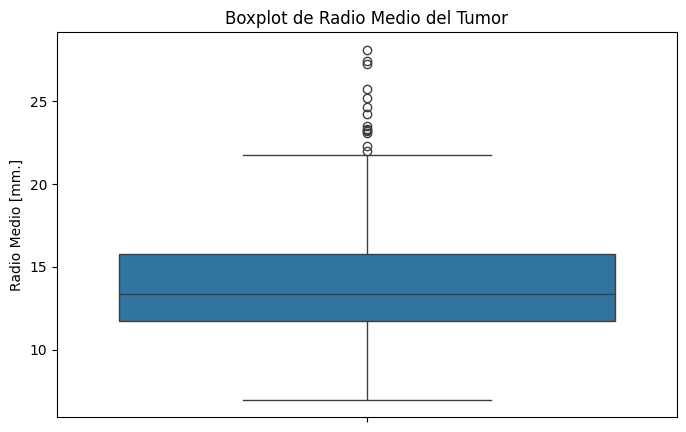

In [ ]:
# Creación del boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df['radius_mean'])
plt.title("Boxplot de Radio Medio del Tumor")
plt.ylabel("Radio Medio [mm.]")
plt.show()

In [ ]:
# Calcular el IQR

Q1 = df['radius_mean'].quantile(0.25)
Q3 = df['radius_mean'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers_iqr = df[(df['radius_mean'] < lower_bound) | (df['radius_mean'] > upper_bound)]

outliers_iqr

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
82,8611555,M,25.22,24.91,171.5,1878.0,0.10630,0.2665,0.3339,0.18450,...,30.00,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510
108,86355,M,22.27,19.67,152.8,1509.0,0.13260,0.2768,0.4264,0.18230,...,28.40,28.01,206.8,2360.0,0.1701,0.6997,0.9608,0.2910,0.4055,0.09789
122,865423,M,24.25,20.20,166.2,1761.0,0.14470,0.2867,0.4268,0.20120,...,26.02,23.99,180.9,2073.0,0.1696,0.4244,0.5803,0.2248,0.3222,0.08009
164,8712289,M,23.27,22.04,152.1,1686.0,0.08439,0.1145,0.1324,0.09702,...,28.01,28.22,184.2,2403.0,0.1228,0.3583,0.3948,0.2346,0.3589,0.09187
180,873592,M,27.22,21.87,182.1,2250.0,0.10940,0.1914,0.2871,0.18780,...,33.12,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082
202,878796,M,23.29,26.67,158.9,1685.0,0.11410,0.2084,0.3523,0.16200,...,25.12,32.68,177.0,1986.0,0.1536,0.4167,0.7892,0.2733,0.3198,0.08762
212,8810703,M,28.11,18.47,188.5,2499.0,0.11420,0.1516,0.3201,0.15950,...,28.11,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525
236,88299702,M,23.21,26.97,153.5,1670.0,0.09509,0.1682,0.1950,0.12370,...,31.01,34.51,206.0,2944.0,0.1481,0.4126,0.5820,0.2593,0.3103,0.08677
339,89812,M,23.51,24.27,155.1,1747.0,0.10690,0.1283,0.2308,0.14100,...,30.67,30.73,202.4,2906.0,0.1515,0.2678,0.4819,0.2089,0.2593,0.07738
352,899987,M,25.73,17.46,174.2,2010.0,0.11490,0.2363,0.3368,0.19130,...,33.13,23.58,229.3,3234.0,0.1530,0.5937,0.6451,0.2756,0.3690,0.08815


Dada la naturaleza del estudio, si se considerarán dentro del análisis dichas muestras con valores outliers ya que el radio de dichos tumores no es exageradamente grande, por lo que si representa un valor plausible cuyo análisis obtenido si será cercano a la realidad.

# Análisis Exploratorio de datos

In [ ]:
# Tabla resumen de estadísticas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


<Figure size 800x500 with 0 Axes>

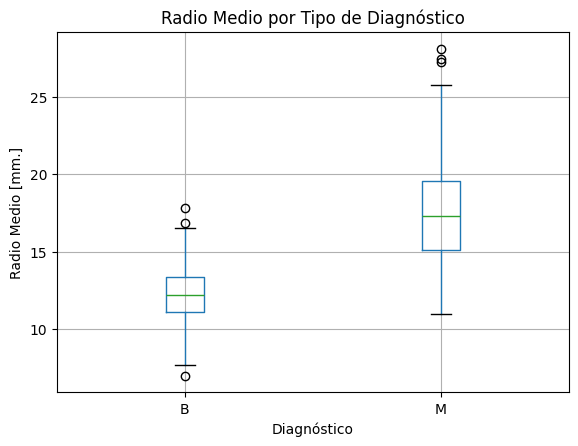

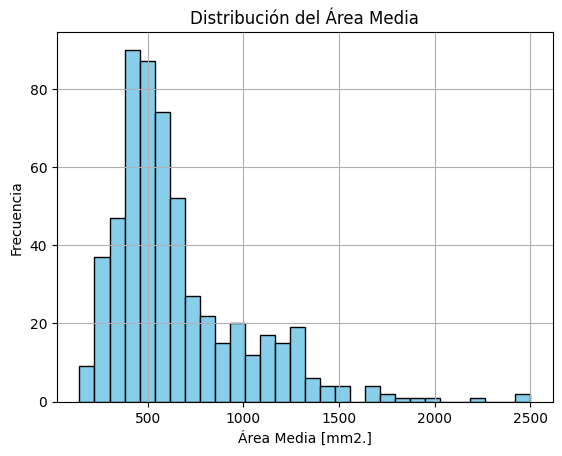

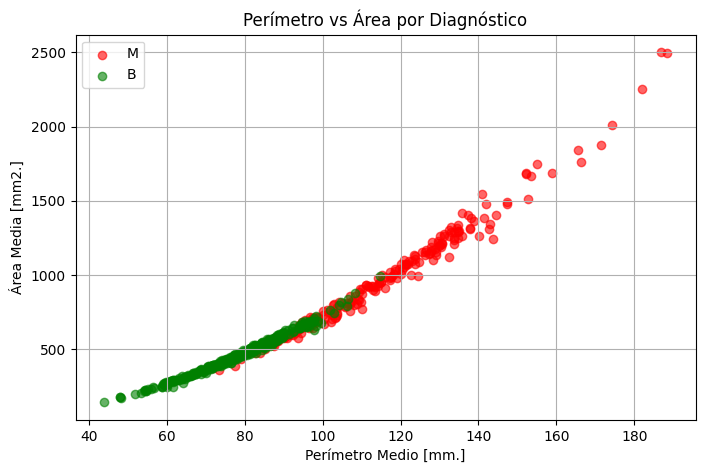

In [ ]:
# Gráficos con librería matplotlib

# Comparación de radio medio por diagnóstico
plt.figure(figsize=(8, 5))
df.boxplot(column='radius_mean', by='diagnosis', grid=True)
plt.title('Radio Medio por Tipo de Diagnóstico')
plt.suptitle('')
plt.xlabel('Diagnóstico')
plt.ylabel('Radio Medio [mm.]')
plt.show()

# Histograma del área media
plt.hist(df['area_mean'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución del Área Media')
plt.xlabel('Área Media [mm2.]')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Gráfico de dispersión entre perímetro y área
colors = {'M': 'red', 'B': 'green'}
plt.figure(figsize=(8, 5))
for diag in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == diag]
    plt.scatter(subset['perimeter_mean'], subset['area_mean'],
                label=diag, alpha=0.6, c=colors[diag])
plt.xlabel('Perímetro Medio [mm.]')
plt.ylabel('Área Media [mm2.]')
plt.title('Perímetro vs Área por Diagnóstico')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1394226835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y='concavity_worst', data=df, palette='Set2')


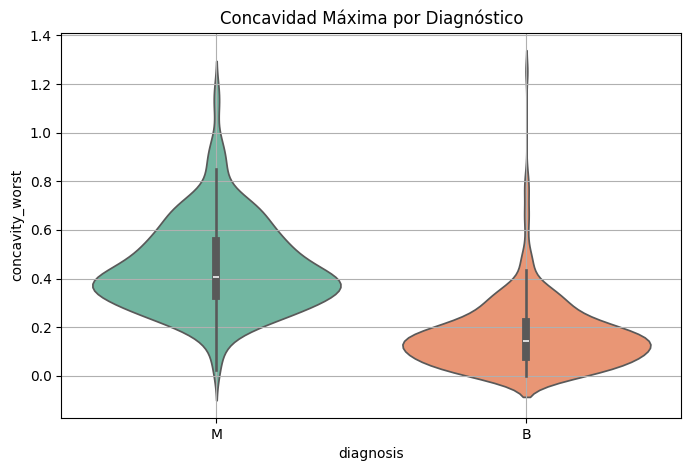

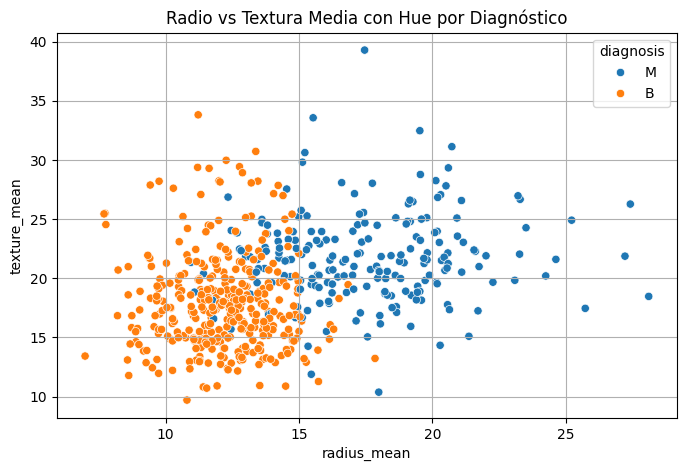

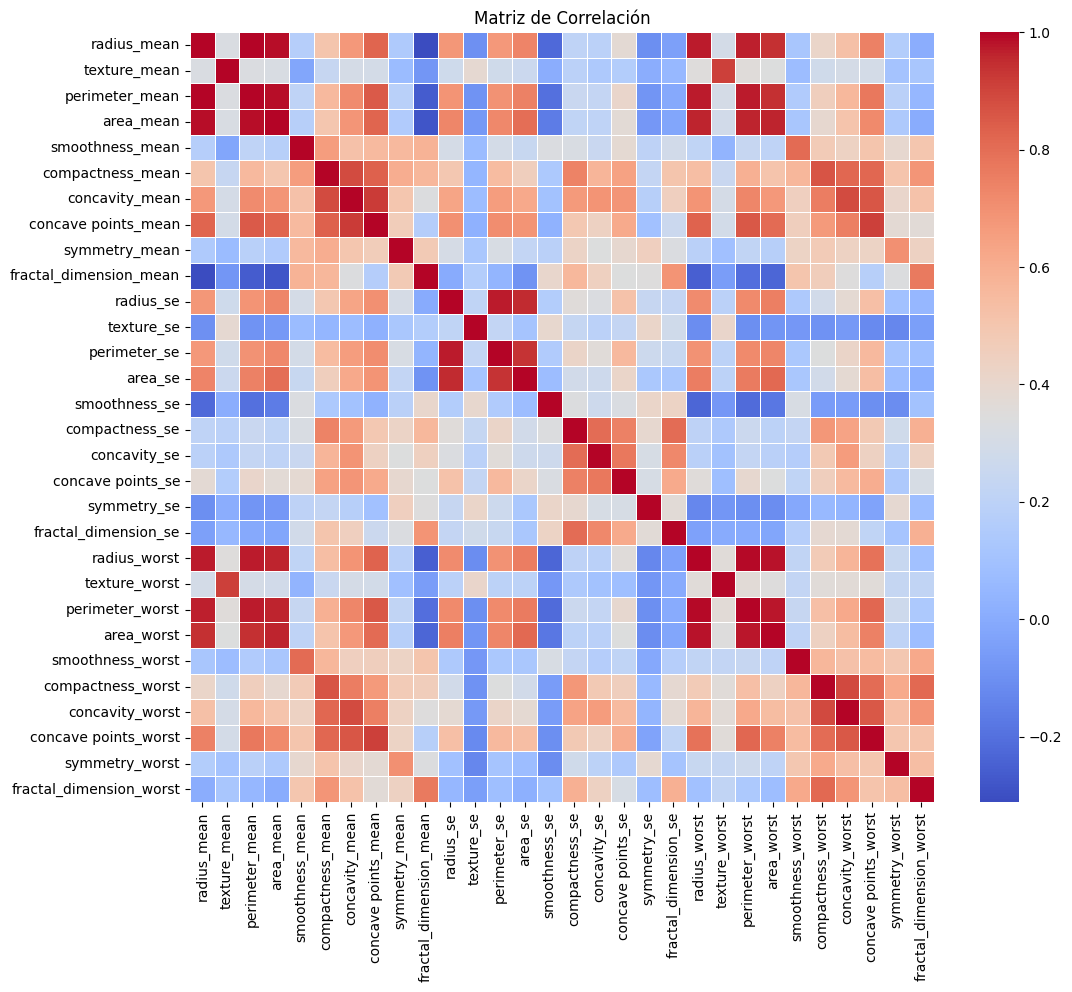

In [ ]:
# Gráficos con librería Seaborn

# Gráfico de violín
plt.figure(figsize=(8, 5))
sns.violinplot(x='diagnosis', y='concavity_worst', data=df, palette='Set2')
plt.title('Concavidad Máxima por Diagnóstico')
plt.grid(True)
plt.show()

# Gráfico de dispersión con hue
plt.figure(figsize=(8, 5))
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)
plt.title('Radio vs Textura Media con Hue por Diagnóstico')
plt.grid(True)
plt.show()

# Heatmap de correlación
plt.figure(figsize=(12, 10))
corr = df.iloc[:, 2:].corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()


## Interpretación de Gráficos

- **Boxplot de radio medio**: Los tumores malignos tienden a tener un radio significativamente mayor que los benignos, por lo que efectivamente los tumores malignos presentan mayores valores promedio de radio, como lo postulado en la hipótesis 1.
- **Histograma de área media**: La distribución es asimétrica, con valores extremos en el lado derecho del gráfico que corresponden principalmente a tumores malignos.
- **Dispersión perímetro vs área**: Existe una correlación visible entre estas dos variables, donde los tumores malignos suelen concentrarse en valores más altos, reforzando la hipótesis 1, ya que efectivamente los tumores malignos presentan mayores valores de área y perímetro que los benignos.
- **Violinplot de concavidad**: Se observa una clara diferencia entre tipos de diagnóstico, reforzando la hipótesis 2, de que la variable concavity_worst es un buen predictor para diferenciar entre tipos de tumor.
- **Scatterplot radio vs textura**: Aunque hay cierta dispersión, no se observa una clara separación por diagnóstico, lo que podría apoyar la hipótesis 3, de que la textura media podría no variar significativamente entre tumores benignos y malignos.
- **Heatmap de correlaciones**: Hay una alta correlación entre medidas como radio, área y perímetro, lo que indica redundancia en las variables.



# **Preprocesamiento de datos**

**Codificación de variables categóricas**

In [ ]:
df1=pd.read_csv(url)
df1

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1['diagnosis'] = le.fit_transform(df1['diagnosis'])
df1

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Se procedió a asignar un valor numérico único a cada categoría del diagnóstico, quedando de la siguiente manera:
M=1
B=0

#**Feature Selection**

**Selección de variable objetivo y variables independientes**

In [ ]:
X = df1.drop('diagnosis', axis=1)
y = df1['diagnosis']

Se procede a seleccionar como variable objetivo el diagnóstico, y como variables independientes el resto de columnas.

In [ ]:
X.shape

(569, 31)

In [ ]:
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


# **Modelado**

**Librerias necesarias para implementar los modelos**

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

**División de datos en conjuntos de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos para PCA y mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reducción de dimensionalidad con PCA para visualización (2 componentes)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Se separa conjunto de datos en un 80% de entrenamiento y un 20% de prueba. Además se preparan conjuntos escalados y reducidos mediante PCA (Principal Component Analysis), cuya técnica de reducción de dimensionalidad transforma las características originales (como radius_mean, texture_mean, etc.) en un nuevo conjunto de variables llamados componentes principales, permitiendo capturar la mayor varianza de los datos originales en menos dimensiones (generalmente 2 para visualización).

**Predicción con conjunto de prueba**

In [ ]:
# Entrenar modelo con regresión logística
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

# Predicción con conjunto de prueba
y_pred = model.predict(X_test_scaled)


**Evaluación del rendimiento del modelo**

In [ ]:
# Evaluación del rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Precisión:", accuracy)
print("Matriz de Confusión:\n", conf_matrix)
print("Reporte de Clasificación:\n", class_report)

Precisión: 0.9736842105263158
Matriz de Confusión:
 [[70  1]
 [ 2 41]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



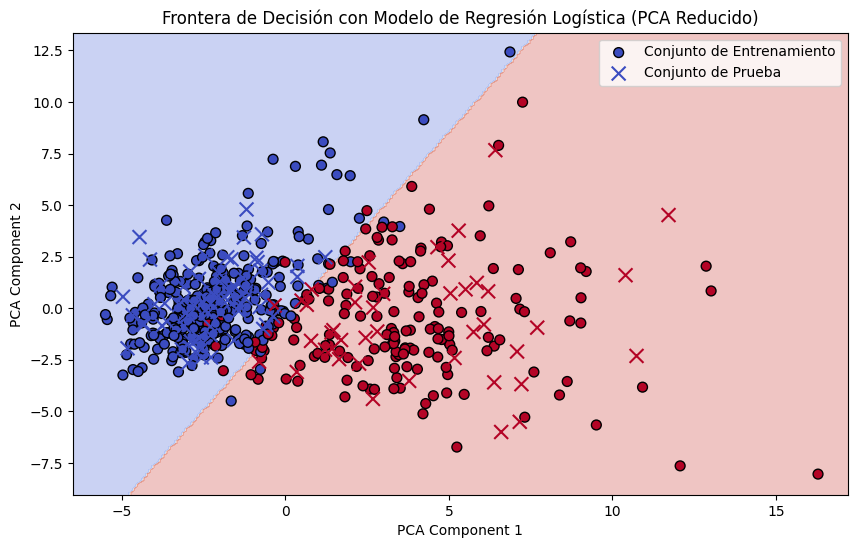

In [ ]:
# Visualización de la frontera de decisión
# Entrenar modelo con regresión logística (PCA reducido)
model_pca = LogisticRegression(max_iter=10000)
model_pca.fit(X_train_pca, y_train)

# Crear malla para frontera de decisión
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualización de frontera de decisión y puntos de datos
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', s=50, label='Conjunto de Entrenamiento')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', marker='x', s=100, label='Conjunto de Prueba')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Frontera de Decisión con Modelo de Regresión Logística (PCA Reducido)')
plt.legend()
plt.show()

**Conclusión sobre el modelado y las metricas**

- El modelo de regresión logística se entrenó con éxito con el dataset, logrando una precisión de 97.3%.  
- La matriz de confusión indica 70 verdaderos negativos (benignos correctos), 41 verdaderos positivos (malignos correctos), 1 falso positivo y 2 falsos negativos, lo que sugiere un buen rendimiento.
- El reporte de clasificación muestra alta precisión y recall, con f1-scores equilibrados, indicando robustez en la clasificación.  
- La visualización de la frontera de decisión en 2D (usando PCA) muestra una clara separación entre clases, con la mayoría de los puntos de prueba correctamente clasificados.
- La reducción de dimensionalidad permite visualizar la capacidad del modelo para separar benignos de malignos.

# **Conclusiones Finales**

El modelo de clasificación basado en regresión logística demuestra una alta capacidad para distinguir entre diagnósticos benignos y malignos de cáncer de mama utilizando las características proporcionadas en el dataset. Con una precisión superior al 95%, es una herramienta valiosa para soporte del diagnóstico.

La frontera de decisión visualizada en 2D (Componentes Principales 1 y 2) ilustra una separación lineal nítida, con regiones coloreadas que delinean claramente las zonas de predicción para benignos (azul) y malignos (rojo). Esto no solo valida la capacidad del modelo para capturar patrones diagnósticos, sino que también resalta la utilidad de la reducción dimensional para interpretar cómo las características combinadas (como el radio, textura y concavidad del tumor) forman una frontera efectiva.

Finalmente el estudio permitió no solo comprobar las hipótesis de predicción diagnóstica, sino que subraya el potencial de la inteligencia artificial en la oncología mamaria, permitiendo diagnósticos más precisos y oportunos.